In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import pandas as pd

# Load the production model
model = joblib.load('military_ids_model.pkl')

# External Validation on Bot-IoT dataset
df_bot = pd.read_csv('Bot-IoT.csv')
# Pre-processing to match training features
# (You would add logic here to align Bot-IoT columns with UNSW columns)

print("Generating Robustness Metrics...")
# Placeholder for prediction and CM visualization logic from your figures notebook

Generating Robustness Metrics...


In [3]:
# --- Section 1: Setup & Data Loading ---
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

# Load datasets based on your uploaded files
# Note: Ensure the CSV files are in the same directory
df_train = pd.read_csv('UNSW_NB15_training-set.csv')
df_test = pd.read_csv('UNSW_NB15_testing-set.csv')

# --- Section 2: Feature Engineering (Interrelation Logic) ---
# Train directly on attack_cat so the app can show real threat families
drop_cols = ['id', 'proto', 'service', 'state', 'attack_cat']
X = df_train.drop(drop_cols + ['label'], axis=1)
y = df_train['attack_cat']

# Stratify so the rare classes like Worms remain represented in validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# --- Section 3: Targeted Rare-Class Rebalancing ---
# Oversample the weakest families so the classifier sees more Analysis, Backdoor, Worms, and Shellcode examples
train_df = X_train.copy()
train_df['attack_cat'] = y_train.values
resample_targets = {
    'Analysis': 4000,
    'Backdoor': 4000,
    'Worms': 2000,
    'Shellcode': 2500,
}
augmented_parts = [train_df]
for attack_name, target_size in resample_targets.items():
    subset = train_df[train_df['attack_cat'] == attack_name]
    if len(subset) < target_size:
        augmented_parts.append(
            resample(
                subset,
                replace=True,
                n_samples=target_size - len(subset),
                random_state=32,
            )
        )
augmented_train_df = pd.concat(augmented_parts, ignore_index=True)
X_train_balanced = augmented_train_df.drop(columns=['attack_cat'])
y_train_balanced = augmented_train_df['attack_cat']

# --- Section 4: Robust Pipeline Construction ---
# Balanced random forest plus targeted oversampling gives better recall on the rarest families
ids_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=160,
        max_depth=40,
        class_weight='balanced_subsample',
        n_jobs=1,
        random_state=32,
    ))
])

# Training on multiclass data after targeted rare-class rebalancing
ids_pipeline.fit(X_train_balanced, y_train_balanced)
val_pred = ids_pipeline.predict(X_val)
print('Training Complete.')
print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(classification_report(y_val, val_pred, zero_division=0))

# --- Section 5: Model Export ---
model_filename = 'military_ids_model.pkl'
joblib.dump(ids_pipeline, model_filename)
# Export feature names so the UI knows which inputs to ask for
joblib.dump(X_train_balanced.columns.tolist(), 'feature_names.pkl')
print(f"Model and features successfully exported to {model_filename}")
print(f"Exported classes: {list(ids_pipeline.classes_)}")

Training Complete.
Validation accuracy: 0.7794
                precision    recall  f1-score   support

      Analysis       0.04      0.16      0.06       400
      Backdoor       0.04      0.21      0.06       349
           DoS       0.32      0.31      0.32      2453
      Exploits       0.82      0.57      0.67      6679
       Fuzzers       0.77      0.74      0.76      3637
       Generic       1.00      0.98      0.99      8000
        Normal       0.94      0.93      0.94     11200
Reconnaissance       0.92      0.73      0.81      2098
     Shellcode       0.62      0.71      0.66       227
         Worms       0.59      0.65      0.62        26

      accuracy                           0.78     35069
     macro avg       0.61      0.60      0.59     35069
  weighted avg       0.85      0.78      0.81     35069

Model and features successfully exported to military_ids_model.pkl
Exported classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reco

In [5]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

df_train = pd.read_csv('UNSW_NB15_training-set.csv')
df_test = pd.read_csv('UNSW_NB15_testing-set.csv')

drop_cols = ['id', 'proto', 'service', 'state', 'attack_cat']
X = df_train.drop(drop_cols + ['label'], axis=1)
y = df_train['attack_cat']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

train_df = X_train.copy()
train_df['attack_cat'] = y_train

resample_targets = {
    'Analysis': 4000,
    'Backdoor': 4000,
    'Worms': 2000,
    'Shellcode': 2500,
}

label_map = {label: idx for idx, label in enumerate(le.classes_)}

augmented_parts = [train_df]

for attack_name, target_size in resample_targets.items():
    if attack_name in label_map:
        class_id = label_map[attack_name]
        subset = train_df[train_df['attack_cat'] == class_id]
        if len(subset) < target_size:
            augmented_parts.append(
                resample(
                    subset,
                    replace=True,
                    n_samples=target_size - len(subset),
                    random_state=32,
                )
            )

augmented_train_df = pd.concat(augmented_parts, ignore_index=True)

X_train_balanced = augmented_train_df.drop(columns=['attack_cat'])
y_train_balanced = augmented_train_df['attack_cat']

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=45,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=32
)

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=32
)

rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_val)

print("\nRandom Forest Results")
print(f"Accuracy: {accuracy_score(y_val, rf_pred):.4f}")
print(classification_report(y_val, rf_pred, zero_division=0))

xgb_model.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb_model.predict(X_val)

print("\nXGBoost Results")
print(f"Accuracy: {accuracy_score(y_val, xgb_pred):.4f}")
print(classification_report(y_val, xgb_pred, zero_division=0))

final_model = xgb_model

joblib.dump(final_model, 'military_ids_model2.pkl')
joblib.dump(X_train_balanced.columns.tolist(), 'feature_names2.pkl')
joblib.dump(le, 'label_encoder2.pkl')

print("\nFinal Model Saved: XGBoost")
print(f"Classes: {list(le.classes_)}")


Random Forest Results
Accuracy: 0.7809
              precision    recall  f1-score   support

           0       0.04      0.15      0.06       400
           1       0.04      0.21      0.06       349
           2       0.32      0.32      0.32      2453
           3       0.82      0.57      0.67      6679
           4       0.78      0.74      0.76      3637
           5       1.00      0.98      0.99      8000
           6       0.94      0.93      0.94     11200
           7       0.92      0.73      0.82      2098
           8       0.64      0.76      0.69       227
           9       0.62      0.69      0.65        26

    accuracy                           0.78     35069
   macro avg       0.61      0.61      0.60     35069
weighted avg       0.85      0.78      0.81     35069


XGBoost Results
Accuracy: 0.8325
              precision    recall  f1-score   support

           0       0.59      0.15      0.24       400
           1       0.43      0.13      0.20       349
    


Final Ensemble Results
Accuracy: 0.7828
              precision    recall  f1-score   support

           0       0.05      0.18      0.07       400
           1       0.03      0.20      0.06       349
           2       0.32      0.24      0.28      2453
           3       0.78      0.60      0.67      6679
           4       0.79      0.75      0.77      3637
           5       1.00      0.98      0.99      8000
           6       0.95      0.93      0.94     11200
           7       0.91      0.73      0.81      2098
           8       0.59      0.77      0.67       227
           9       0.63      0.85      0.72        26

    accuracy                           0.78     35069
   macro avg       0.60      0.62      0.60     35069
weighted avg       0.84      0.78      0.81     35069



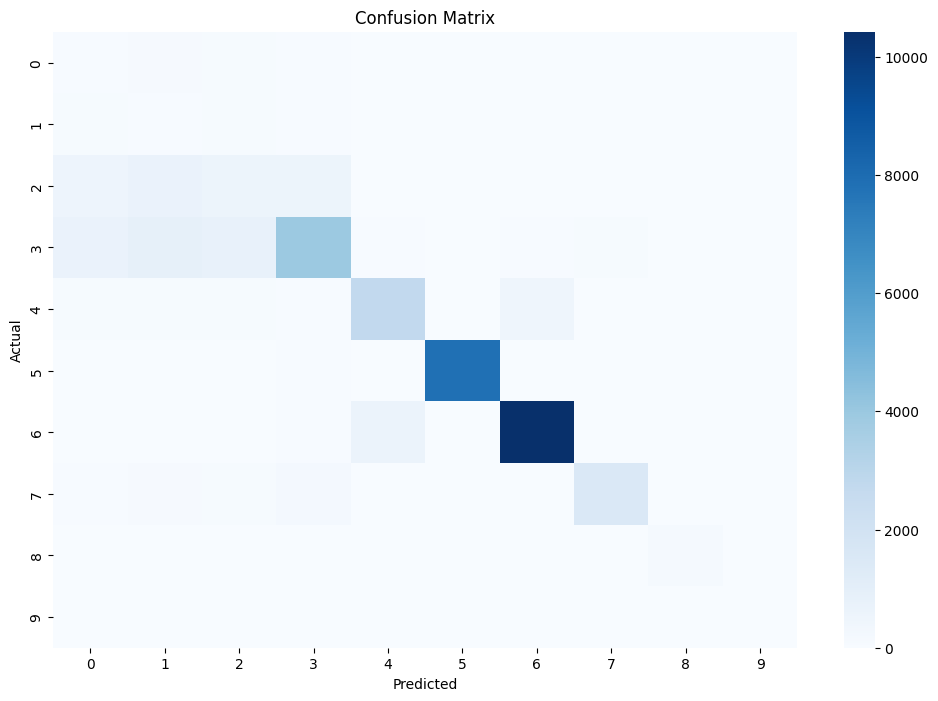


Final Model Saved (Ensemble)
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [6]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectFromModel

from xgboost import XGBClassifier

# ------------------ LOAD DATA ------------------
df_train = pd.read_csv('UNSW_NB15_training-set.csv')

drop_cols = ['id', 'proto', 'service', 'state', 'attack_cat']
X = df_train.drop(drop_cols + ['label'], axis=1)
y = df_train['attack_cat']

# ------------------ ENCODE LABELS ------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ------------------ SPLIT ------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ------------------ AGGRESSIVE OVERSAMPLING ------------------
train_df = X_train.copy()
train_df['attack_cat'] = y_train

label_map = {label: idx for idx, label in enumerate(le.classes_)}

resample_targets = {
    'Analysis': 8000,
    'Backdoor': 8000,
    'Worms': 5000,
    'Shellcode': 6000,
}

augmented_parts = [train_df]

for attack_name, target_size in resample_targets.items():
    if attack_name in label_map:
        class_id = label_map[attack_name]
        subset = train_df[train_df['attack_cat'] == class_id]

        if len(subset) < target_size:
            augmented_parts.append(
                resample(
                    subset,
                    replace=True,
                    n_samples=target_size,
                    random_state=32
                )
            )

augmented_train_df = pd.concat(augmented_parts, ignore_index=True)

X_train_balanced = augmented_train_df.drop(columns=['attack_cat'])
y_train_balanced = augmented_train_df['attack_cat']

# ------------------ FEATURE SELECTION ------------------
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=32),
    threshold='median'
)

X_train_balanced = selector.fit_transform(X_train_balanced, y_train_balanced)
X_val = selector.transform(X_val)

# ------------------ MODELS ------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=45,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=32
)

xgb_model = XGBClassifier(
    n_estimators=800,
    max_depth=14,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    min_child_weight=3,
    reg_alpha=0.5,
    reg_lambda=1.5,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=32
)

# ------------------ ENSEMBLE ------------------
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

# ------------------ TRAIN ------------------
ensemble.fit(X_train_balanced, y_train_balanced)

# ------------------ PREDICT ------------------
y_pred = ensemble.predict(X_val)

# ------------------ RESULTS ------------------
print("\nFinal Ensemble Results")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred, zero_division=0))

# ------------------ CONFUSION MATRIX ------------------
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------ SAVE MODEL ------------------
joblib.dump(ensemble, 'military_ids_model3.pkl')
joblib.dump(selector, 'feature_selector3.pkl')
joblib.dump(le, 'label_encoder3.pkl')
joblib.dump(X.columns.tolist(), 'feature_names3.pkl')

print("\nFinal Model Saved (Ensemble)")
print(f"Classes: {list(le.classes_)}")


Final XGBoost Results
Accuracy: 0.8295
              precision    recall  f1-score   support

           0       0.38      0.15      0.22       400
           1       0.26      0.13      0.18       349
           2       0.34      0.17      0.22      2453
           3       0.63      0.87      0.73      6679
           4       0.79      0.76      0.77      3637
           5       1.00      0.98      0.99      8000
           6       0.95      0.93      0.94     11200
           7       0.92      0.73      0.81      2098
           8       0.65      0.76      0.70       227
           9       0.67      0.69      0.68        26

    accuracy                           0.83     35069
   macro avg       0.66      0.62      0.62     35069
weighted avg       0.82      0.83      0.82     35069



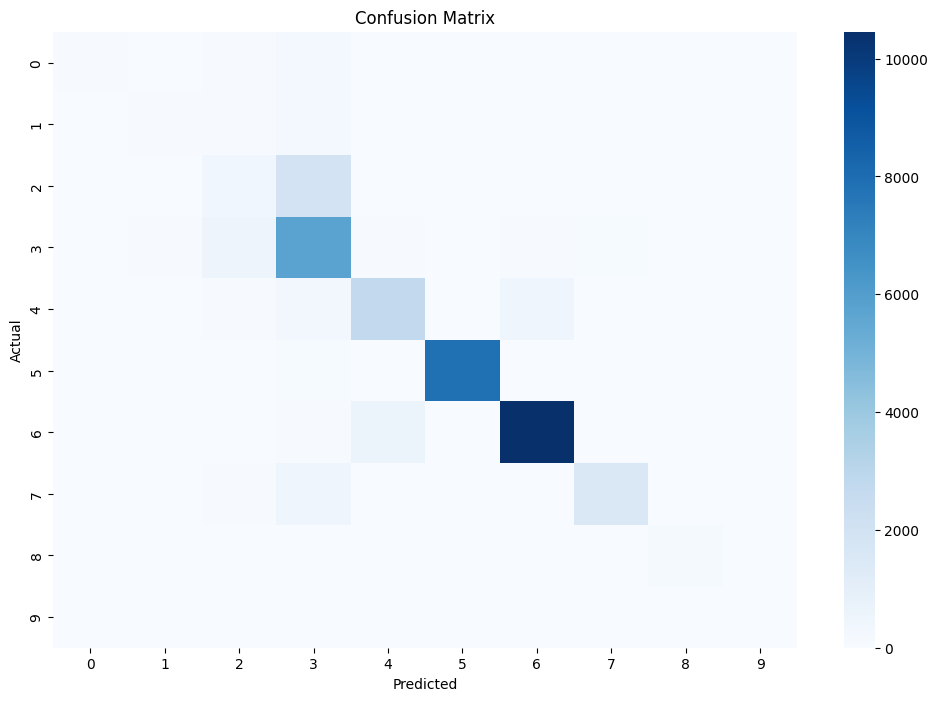


Final Model Saved (XGBoost)
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [7]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

from xgboost import XGBClassifier

# ------------------ LOAD DATA ------------------
df_train = pd.read_csv('UNSW_NB15_training-set.csv')

drop_cols = ['id', 'proto', 'service', 'state', 'attack_cat']
X = df_train.drop(drop_cols + ['label'], axis=1)
y = df_train['attack_cat']

# ------------------ ENCODE LABELS ------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ------------------ SPLIT ------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ------------------ MODERATE OVERSAMPLING ------------------
train_df = X_train.copy()
train_df['attack_cat'] = y_train

label_map = {label: idx for idx, label in enumerate(le.classes_)}

resample_targets = {
    'Analysis': 4000,
    'Backdoor': 4000,
    'Worms': 2000,
    'Shellcode': 2500,
}

augmented_parts = [train_df]

for attack_name, target_size in resample_targets.items():
    if attack_name in label_map:
        class_id = label_map[attack_name]
        subset = train_df[train_df['attack_cat'] == class_id]

        if len(subset) < target_size:
            augmented_parts.append(
                resample(
                    subset,
                    replace=True,
                    n_samples=target_size,
                    random_state=32
                )
            )

augmented_train_df = pd.concat(augmented_parts, ignore_index=True)

X_train_balanced = augmented_train_df.drop(columns=['attack_cat'])
y_train_balanced = augmented_train_df['attack_cat']

# ------------------ XGBOOST MODEL ------------------
model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.07,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    min_child_weight=2,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=32
)

# ------------------ TRAIN ------------------
model.fit(X_train_balanced, y_train_balanced)

# ------------------ PREDICT ------------------
y_pred = model.predict(X_val)

# ------------------ RESULTS ------------------
print("\nFinal XGBoost Results")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred, zero_division=0))

# ------------------ CONFUSION MATRIX ------------------
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------ SAVE ------------------
joblib.dump(model, 'military_ids_model4.pkl')
joblib.dump(le, 'label_encoder4.pkl')
joblib.dump(X.columns.tolist(), 'feature_names4.pkl')

print("\nFinal Model Saved (XGBoost)")
print(f"Classes: {list(le.classes_)}")